<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/02_Clasificación_lineal/ova.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [10]:
#########################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)              #
# E-mail: wgomez@cinvestav.mx                           #
# Curso:  Análisis de datos                             #
# Tópico: Clasificación multiclase uno contra todos     #
#########################################################

Carga bibliotecas necesarias

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [12]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [14]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Entrenamiento del clasificador binario basado en LDA

In [15]:
def lda(X, Y, i):
    ci = (Y == i).flatten() # Muestras de la i-esima clase
    cj = (Y != i).flatten() # Muestras del resto de las clases
    Cn = X[cj, :]
    Cp = X[ci, :]
    MUn = np.mean(Cn, axis=0, keepdims=True)
    MUp = np.mean(Cp, axis=0, keepdims=True)
    Cn = Cn - MUn
    Cp = Cp - MUp
    SW = (1 / (X.shape[0] - 2)) * ((Cn.T @ Cn) + (Cp.T @ Cp)) # Matriz de dispersion intraclase
    W = np.linalg.pinv(SW) @ (MUp - MUn).T # Pesos
    b = -0.5 * (MUp + MUn) # Bias
    return W, b

Entrenamiento multiclase con estrategia uno contra todos (OVA)

In [16]:
def ova_train(X, Y):
    d = X.shape[1] # Número de variables
    c = len(np.unique(Y)) # Número de clases
    W = np.zeros((d, c))
    b = np.zeros((c, d))
    for i in range(c):
        Wi, bi = lda(X, Y, i) # Entrena i-ésima clase vs. el resto
        W[:, i] = Wi.flatten() # Salva vector de pesos
        b[i, :] = bi.flatten() # Salva el bias
    return W, b

Predicción multiclase con estrategia OVA

In [17]:
def ova_predict(X, W, b):
    c = b.shape[0] # Número de clases
    n = X.shape[0] # Número de muestras de prueba
    r = np.zeros((n, c)) # Vector de respuestas para cada muestra de prueba
    for i in range(c):
        r[:, i] = (X + b[i, :]) @ W[:, i] # Evalua el i-ésimo clasificador lineal
    Y_pred = np.argmax(r, axis=1) # Clasifica por máxima confianza
    Y_pred = Y_pred.reshape(-1, 1) # Asegurar vector columna
    return Y_pred


Entrenamiento y clasificación con OVA

In [18]:
# Entrena los c clasificadores de OVA
W, b = ova_train(X_train, Y_train)
# Clasifica
Y_pred = ova_predict(X_test, W, b)

Visualiza matriz de confusión

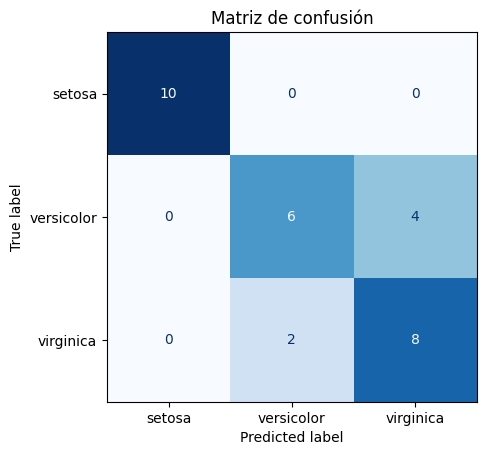

Exactitud: 0.800


In [19]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
ACC = np.mean(Y_pred == Y_test)
print(f"Exactitud: {ACC:.3f}")